# 파인튜닝 전후 성능 비교

## 베이스라인 모델, KLUE-BERT 일반 파인튜닝 모델, KLUE-BERT LoRA 파인튜닝 모델 비교

이번 단계에서는 기존 베이스라인 모델과 KLUE-BERT 일반 파인튜닝 모델, KLUE-BERT LoRA 파인튜닝 모델의 성능을 비교한다.

베이스라인 모델은 TF-IDF 벡터화를 적용한 뒤 Logistic Regression과 Linear SVM으로 악성 댓글 이진 분류를 수행한 결과이다. 일반 파인튜닝 모델은 KLUE-BERT 전체 파라미터를 악성 댓글 분류 태스크에 맞게 추가 학습한 결과이며, LoRA 파인튜닝 모델은 KLUE-BERT에 LoRA adapter를 적용하여 효율적으로 파인튜닝한 결과이다.

비교 지표는 Accuracy, Precision, Recall, F1-score를 사용한다.

모든 모델은 동일한 `data/processed/valid_processed.csv` 기준으로 평가된 결과를 사용하여 비교한다.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

## 성능 비교 데이터 구성

각 모델의 평가 결과를 하나의 표로 정리한다.

비교에는 베이스라인 모델의 예측 결과와 KLUE-BERT, KLUE-BERT LoRA 모델의 평가 지표를 사용했다.

- `reports/Logistic_Regression_predictions.csv`
- `reports/Linear_SVM_predictions.csv`
- `reports/KLUE_BERT_metrics.csv`
- `reports/KLUE_BERT_LoRA_metrics.csv`

In [7]:
comparison_df = pd.DataFrame(
    [
        {
            "stage": "Baseline",
            "model": "Logistic Regression",
            "accuracy": 0.6583,
            "precision": 0.6569,
            "recall": 0.8265,
            "f1": 0.7320,
        },
        {
            "stage": "Baseline",
            "model": "Linear SVM",
            "accuracy": 0.6458,
            "precision": 0.6670,
            "recall": 0.7439,
            "f1": 0.7034,
        },
        {
            "stage": "Fine-tuning",
            "model": "KLUE-BERT",
            "accuracy": 0.7814,
            "precision": 0.8309,
            "recall": 0.7693,
            "f1": 0.7989,
        },
        {
            "stage": "LoRA fine-tuning",
            "model": "KLUE-BERT LoRA",
            "accuracy": 0.7838,
            "precision": 0.8091,
            "recall": 0.8074,
            "f1": 0.8083,
        },
    ]
)

comparison_df

,stage,model,accuracy,precision,recall,f1
0,Baseline,Logistic Regression,0.6583,0.6569,0.8265,0.7320
1,Baseline,Linear SVM,0.6458,0.6670,0.7439,0.7034
2,Fine-tuning,KLUE-BERT,0.7814,0.8309,0.7693,0.7989
3,LoRA fine-tuning,KLUE-BERT LoRA,0.7838,0.8091,0.8074,0.8083


## 성능 비교 결과 저장

성능 비교 결과를 이후 보고서 작성이나 발표 자료에 활용할 수 있도록 CSV 파일로 저장한다.

In [8]:
comparison_df.to_csv(
    "../reports/model_performance_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

## 성능 비교 시각화

모델별 Accuracy, Precision, Recall, F1-score를 막대그래프로 비교한다.

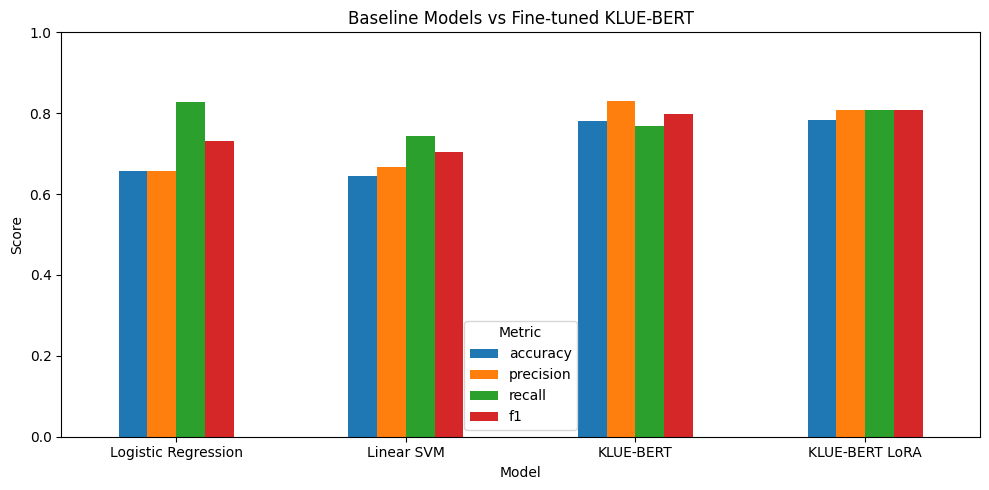

In [9]:
ax = comparison_df.set_index("model")[["accuracy", "precision", "recall", "f1"]].plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1),
)

plt.title("Baseline Models vs Fine-tuned KLUE-BERT")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig("../reports/model_performance_comparison.png", dpi=300)
plt.show()

## Confusion Matrix 비교

각 모델의 Confusion Matrix를 함께 확인하여 정상 댓글과 악성 댓글의 오분류 경향을 비교한다.

### Logistic Regression

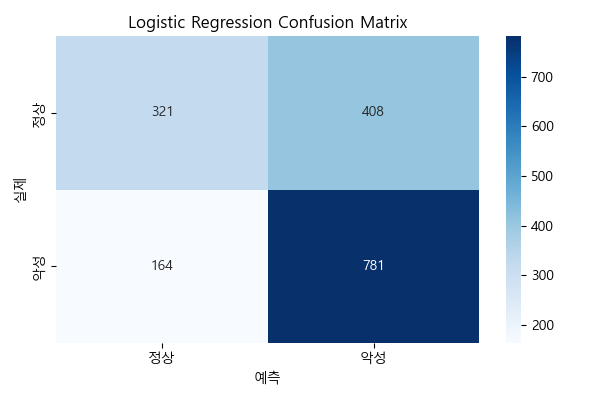

### Linear SVM

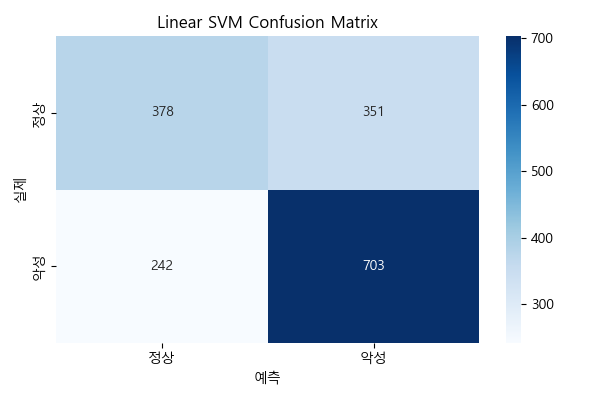

### KLUE-BERT

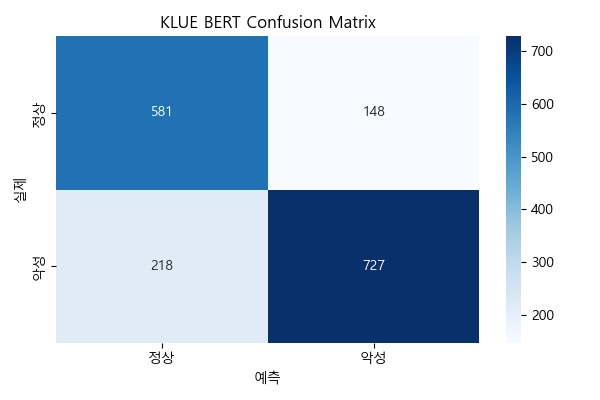

### KLUE-BERT LoRA

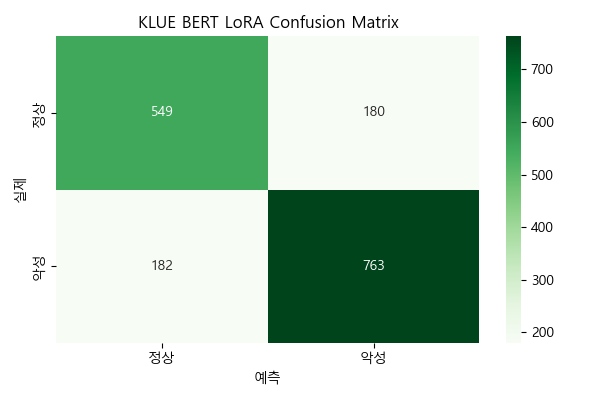

In [10]:
from IPython.display import Image, display, Markdown

confusion_matrix_files = {
    "Logistic Regression": "../reports/Logistic_Regression_confusion_matrix.png",
    "Linear SVM": "../reports/Linear_SVM_confusion_matrix.png",
    "KLUE-BERT": "../reports/KLUE_BERT_confusion_matrix.png",
    "KLUE-BERT LoRA": "../reports/KLUE_BERT_LoRA_confusion_matrix.png",
}

for model_name, file_path in confusion_matrix_files.items():
    display(Markdown(f"### {model_name}"))
    display(Image(filename=file_path))

## 결과 해석

KLUE-BERT LoRA 파인튜닝 모델은 Accuracy 0.7838, Precision 0.8091, Recall 0.8074, F1-score 0.8083을 기록했다.

기존 베이스라인 모델과 비교했을 때 KLUE-BERT 일반 파인튜닝 모델과 KLUE-BERT LoRA 파인튜닝 모델 모두 Accuracy와 F1-score에서 더 높은 성능을 보였다. 특히 F1-score는 Logistic Regression 0.7320, Linear SVM 0.7034보다 KLUE-BERT 0.7989, KLUE-BERT LoRA 0.8083으로 향상되었다.

일반 KLUE-BERT 파인튜닝 모델은 Precision이 0.8309로 가장 높아 악성으로 예측한 댓글 중 실제 악성 댓글의 비율이 가장 높았다. 반면 KLUE-BERT LoRA 모델은 Recall이 0.8074로 일반 KLUE-BERT의 0.7693보다 높아 악성 댓글을 더 많이 탐지하는 경향을 보였다.

Confusion Matrix를 비교하면 Logistic Regression은 악성 댓글 Recall이 높지만 정상 댓글을 악성 댓글로 잘못 예측하는 경우가 많았다. Linear SVM은 Logistic Regression보다 정상 댓글 오분류는 줄었지만 악성 댓글을 정상으로 놓치는 경우가 상대적으로 많았다. KLUE-BERT 계열 모델은 베이스라인보다 전체적인 오분류 균형이 더 안정적이었다.

최종적으로 F1-score 기준으로는 KLUE-BERT LoRA 모델이 0.8083으로 가장 좋은 성능을 보였다. 따라서 일반 KLUE-BERT 파인튜닝보다 LoRA 기반 파인튜닝이 악성 댓글 이진 분류에서 소폭 더 좋은 성능을 보였다고 판단된다.

## 생성된 파일

- `reports/model_performance_comparison.csv`: 모델별 Accuracy, Precision, Recall, F1-score 비교 결과
- `reports/model_performance_comparison.png`: 모델별 성능 지표 비교 그래프
- `reports/KLUE_BERT_LoRA_metrics.csv`: KLUE-BERT LoRA 파인튜닝 모델의 평가 지표
- `reports/KLUE_BERT_LoRA_confusion_matrix.png`: KLUE-BERT LoRA 파인튜닝 모델의 Confusion Matrix